In [1]:
data_path = '/kaggle/input/datasets/dhoogla/ember-2018-v2-features/train_ember_2018_v2_features.parquet'
test_path = '/kaggle/input/datasets/dhoogla/ember-2018-v2-features/test_ember_2018_v2_features.parquet'

1. Bắt đầu Fit PCA...
2. Bắt đầu Transform dữ liệu qua PCA...

3. Đang lọc bỏ nhãn -1... Kích thước ban đầu: (799912, 100)
Kích thước X sau khi lọc sạch: (599920, 100)

4. Đang chia tập Train/Val và Scale dữ liệu...

5. Bắt đầu huấn luyện LightGBM...
Training until validation scores don't improve for 30 rounds
[50]	training's auc: 0.974388	valid_1's auc: 0.973261
[100]	training's auc: 0.982826	valid_1's auc: 0.981172
[150]	training's auc: 0.98719	valid_1's auc: 0.985061
[200]	training's auc: 0.989802	valid_1's auc: 0.987164
[250]	training's auc: 0.991584	valid_1's auc: 0.988501
[300]	training's auc: 0.992917	valid_1's auc: 0.98943
[350]	training's auc: 0.993969	valid_1's auc: 0.990113
[400]	training's auc: 0.994825	valid_1's auc: 0.99069
[450]	training's auc: 0.995517	valid_1's auc: 0.991112
[500]	training's auc: 0.996121	valid_1's auc: 0.991502
Did not meet early stopping. Best iteration is:
[500]	training's auc: 0.996121	valid_1's auc: 0.991502

6. Đang đánh giá mô hình trên tập Vali

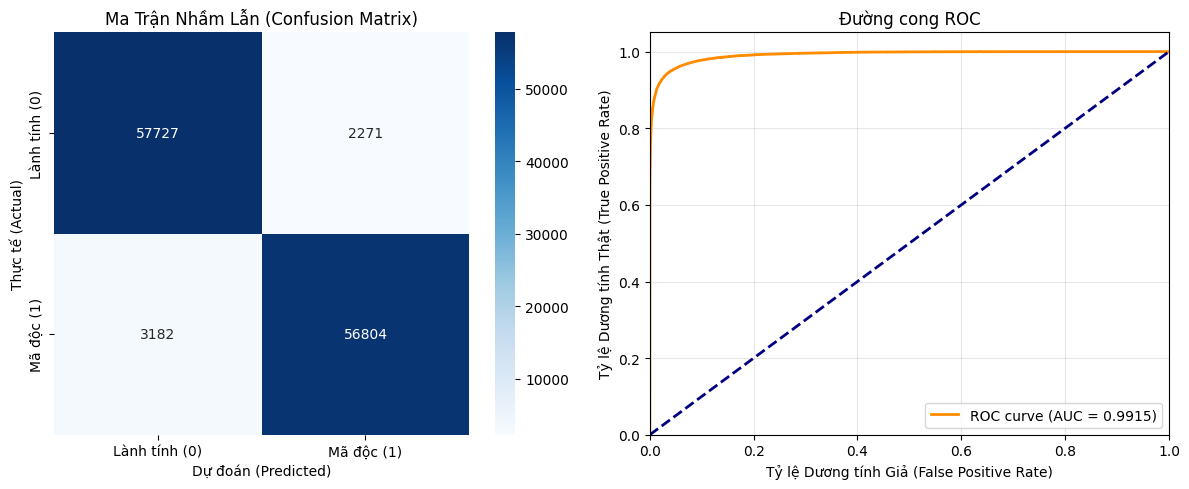

In [2]:
import pyarrow.parquet as pq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import IncrementalPCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import lightgbm as lgb
import gc

data_path = '/kaggle/input/datasets/dhoogla/ember-2018-v2-features/train_ember_2018_v2_features.parquet'
parquet_file = pq.ParquetFile(data_path)

# ==========================================
# BƯỚC 1: FIT & TRANSFORM PCA (Nén 2381 -> 100 features)
# ==========================================
print("1. Bắt đầu Fit PCA...")
ipca = IncrementalPCA(n_components=100)

for batch in parquet_file.iter_batches(batch_size=50000):
    df_batch = batch.to_pandas()
    X_batch = df_batch.drop(columns=['Label']).values if 'Label' in df_batch.columns else df_batch.values
    X_batch = np.nan_to_num(X_batch, nan=0.0, posinf=0.0, neginf=0.0)
    ipca.partial_fit(X_batch)

print("2. Bắt đầu Transform dữ liệu qua PCA...")
X_pca_list, y_list = [], []

for batch in parquet_file.iter_batches(batch_size=50000):
    df_batch = batch.to_pandas()
    y_batch = df_batch['Label'].values if 'Label' in df_batch.columns else np.zeros(len(df_batch))
    X_batch = df_batch.drop(columns=['Label']).values if 'Label' in df_batch.columns else df_batch.values
    X_batch = np.nan_to_num(X_batch, nan=0.0, posinf=0.0, neginf=0.0)
    
    X_pca_list.append(ipca.transform(X_batch))
    y_list.append(y_batch)

# Gom batch thành ma trận X, y
X = np.vstack(X_pca_list)
y = np.concatenate(y_list)

# Dọn rác RAM
del X_pca_list, y_list, df_batch, X_batch
gc.collect()

# ==========================================
# BƯỚC 2: LỌC NHÃN -1 & TIỀN XỬ LÝ (PREPROCESS)
# ==========================================
print(f"\n3. Đang lọc bỏ nhãn -1... Kích thước ban đầu: {X.shape}")
mask = (y != -1.0)
X_clean = X[mask]
y_clean = y[mask]
print(f"Kích thước X sau khi lọc sạch: {X_clean.shape}")

print("\n4. Đang chia tập Train/Val và Scale dữ liệu...")
X_train, X_val, y_train, y_val = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# ==========================================
# BƯỚC 3: MODELING & TUNING VỚI LIGHTGBM
# ==========================================
print("\n5. Bắt đầu huấn luyện LightGBM...")

train_data = lgb.Dataset(X_train_scaled, label=y_train)
val_data = lgb.Dataset(X_val_scaled, label=y_val, reference=train_data)

# Hyperparameters
params = {
    'objective': 'binary',
    'metric': 'auc',       
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 128,
    'max_depth': -1,
    'feature_fraction': 0.8, 
    'random_state': 42,
    'n_jobs': -1,         
    'verbose': -1         
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(50)]
)

# ==========================================
# BƯỚC 4: EVALUATE (Đánh giá)
# ==========================================
print("\n6. Đang đánh giá mô hình trên tập Validation...")
# Lấy dự đoán xác suất (từ mô hình tốt nhất nhờ early_stopping)
y_pred_prob = model.predict(X_val_scaled, num_iteration=model.best_iteration)
y_pred = (y_pred_prob >= 0.5).astype(int)

# 4.1 Báo cáo Classification
print("\n" + "="*40)
print("--- CLASSIFICATION REPORT ---")
print("="*40)
print(classification_report(y_val, y_pred, digits=4))

# 4.2 Vẽ Ma trận nhầm lẫn
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Lành tính (0)', 'Mã độc (1)'], 
            yticklabels=['Lành tính (0)', 'Mã độc (1)'])
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix)')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')

# 4.3 Vẽ đường cong ROC
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính Giả (False Positive Rate)')
plt.ylabel('Tỷ lệ Dương tính Thật (True Positive Rate)')
plt.title('Đường cong ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()